In [3]:
"""
NUFFTのフーリエ変換について、y軸方向の向きを確認したい。つまり、ピクセル座標が大きくなるほど「下」に行くけど、フーリ変換する時はどう扱われているのか知りたい。
"""

'\nNUFFTのフーリエ変換について、y軸方向の向きを確認したい。つまり、ピクセル座標が大きくなるほど「下」に行くけど、フーリ変換する時はどう扱われているのか知りたい。\n'

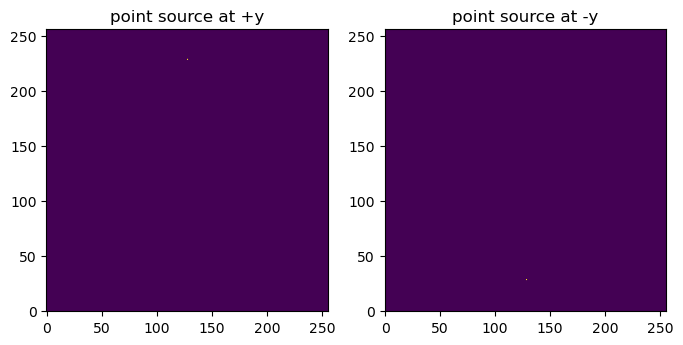

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import finufft
from glint.lensing import make_grid_arcsec

ARCSEC2RAD = np.deg2rad(1/3600)

# -----------------------------
# image grid
# -----------------------------
nx = ny = 256
pix_as = 0.01   # arcsec / pixel

x0_img, y0_img = 0.0, 0.0
xx_as, yy_as = make_grid_arcsec(nx=nx, ny=ny, pixscale_arcsec=pix_as, x0_arcsec=x0_img, y0_arcsec=y0_img)


l_rad = (xx_as * ARCSEC2RAD).ravel().astype(np.float32)
m_rad = (yy_as * ARCSEC2RAD).ravel().astype(np.float32)

# -----------------------------
# 点源画像を作る
# 例: 中心から100 pixel 上 / 下
# -----------------------------
img_up = np.zeros((ny, nx), dtype=np.float32)
img_down = np.zeros((ny, nx), dtype=np.float32)

ix0 = nx // 2
iy0 = ny // 2

dy_pix = 100

img_up[iy0 + dy_pix, ix0] = 1.0
img_down[iy0 - dy_pix, ix0] = 1.0

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_up, origin="lower")
plt.title("point source at +y")
plt.subplot(1,2,2)
plt.imshow(img_down, origin="lower")
plt.title("point source at -y")
plt.show()

In [4]:
# -----------------------------
# uv sampling
# -----------------------------
nvis = 5000
u = np.random.uniform(-5e5, 5e5, nvis).astype(np.float32)
v = np.random.uniform(-5e5, 5e5, nvis).astype(np.float32)

kx = (2*np.pi*u).astype(np.float32)
ky = (2*np.pi*v).astype(np.float32)

In [5]:
vis_up = finufft.nufft2d3(
    x=l_rad,
    y=m_rad,
    c=img_up.ravel().astype(np.complex64),
    s=kx,
    t=ky,
    isign=+1,
    eps=1e-6
)

vis_down = finufft.nufft2d3(
    x=l_rad,
    y=m_rad,
    c=img_down.ravel().astype(np.complex64),
    s=kx,
    t=ky,
    isign=+1,
    eps=1e-6
)

In [6]:
# 点源位置（rad）
l0 = 0.0
m0 = (dy_pix * pix_as) * ARCSEC2RAD

vis_up_th = np.exp(1j * 2*np.pi * (u*l0 + v*m0))
vis_down_th = np.exp(1j * 2*np.pi * (u*l0 - v*m0))

In [10]:
print("max |vis_up - theory|   =", np.max(np.abs(vis_up - vis_up_th)))
print("max |vis_down - theory| =", np.max(np.abs(vis_down - vis_down_th)))
print("max |vis_down - conj(vis_up)| =", np.max(np.abs(vis_down - np.conj(vis_up))))

max |vis_up - theory|   = 0.15038579973796157
max |vis_down - theory| = 0.15038655832793363
max |vis_down - conj(vis_up)| = 0.29992065


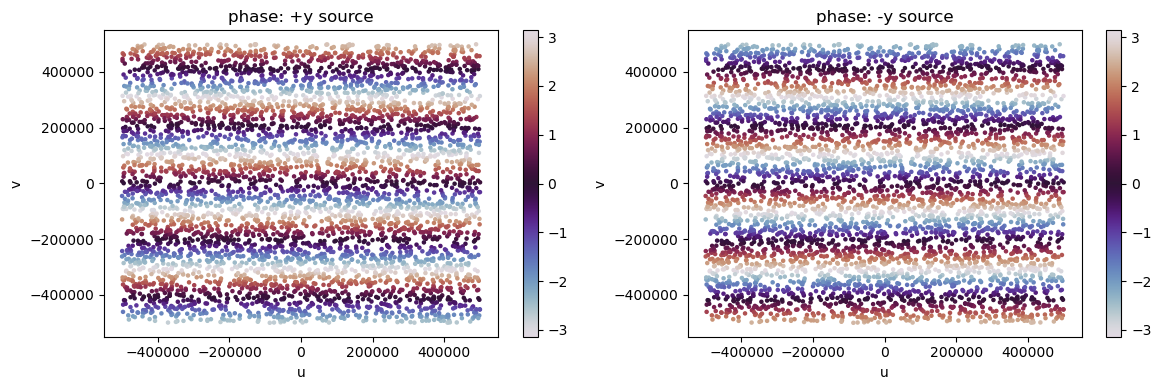

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

im0 = ax[0].scatter(u, v, c=np.angle(vis_up), s=5, cmap="twilight")
ax[0].set_title("phase: +y source")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].scatter(u, v, c=np.angle(vis_down), s=5, cmap="twilight")
ax[1].set_title("phase: -y source")
plt.colorbar(im1, ax=ax[1])

for a in ax:
    a.set_xlabel("u")
    a.set_ylabel("v")

plt.tight_layout()
plt.show()